In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # dutside of the current session

In [4]:
df = pd.read_csv(r"/kaggle/input/datasets/taruntiwarihp/phishing-site-urls/phishing_site_urls.csv") 

In [10]:
df.head(50) 

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad
5,smilesvoegol.servebbs.org/voegol.php,bad
6,premierpaymentprocessing.com/includes/boleto-2...,bad
7,myxxxcollection.com/v1/js/jih321/bpd.com.do/do...,bad
8,super1000.info/docs,bad
9,horizonsgallery.com/js/bin/ssl1/_id/www.paypal...,bad


In [9]:
df.URL

0         nobell.it/70ffb52d079109dca5664cce6f317373782/...
1         www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...
2         serviciosbys.com/paypal.cgi.bin.get-into.herf....
3         mail.printakid.com/www.online.americanexpress....
4         thewhiskeydregs.com/wp-content/themes/widescre...
                                ...                        
549341                                      23.227.196.215/
549342                                   apple-checker.org/
549343                                    apple-iclods.org/
549344                                   apple-uptoday.org/
549345                                    apple-search.info
Name: URL, Length: 549346, dtype: object

In [11]:
df.tail(50)

,URL,Label
549296,www.itcarezone.com/xlrmp/files/anna.exe,bad
549297,alsawmala.com/not16.png,bad
549298,cherishtreeservices.co.uk/cgi_bin/index.php,bad
549299,cherishtreeservices.co.uk/cgi_bin/W/Office365_...,bad
549300,cherishtreeservices.co.uk/cgi_bin/index.php>,bad
549301,pflmethod.com/cgi_bin/>,bad
549302,909.com/site/,bad
549303,asc.avalon-asics.com/?yus=Amaya.129zf113.406f3...,bad
549304,asc.avalon-asics.com/?oq=gWCelTZp_d-L7IBbFe130...,bad
549305,asc.avalon-asics.com/?q=wHzQMvXcJwDNFYbGMvrER6...,bad


In [5]:
df.shape

(549346, 2)

In [6]:
# Checking missing values
missing_val = df.isna().sum()
print(missing_val) 

URL      0
Label    0
dtype: int64


In [7]:
# Total duplicates in the data
dups = df[df.duplicated()]
print(f'Number of duplicates: {len(dups)}') 

Number of duplicates: 42150


In [8]:
df.drop_duplicates(keep='last', inplace=True) 

In [9]:
print(df.duplicated().sum()) 

0


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

print(df['Label'].unique()) 

[0 1]


In [11]:
df.Label.value_counts() 

Label
1    392897
0    114299
Name: count, dtype: int64

In [12]:
df.Label.value_counts(normalize=True) * 100 

Label
1    77.46453
0    22.53547
Name: proportion, dtype: float64

In [13]:
from sklearn.feature_extraction.text import CountVectorizer
import re

def url_tokenizer(url):
    return re.split(r'[/?&.=]', url)

vectorizer = CountVectorizer(tokenizer=url_tokenizer, token_pattern=None)

X = vectorizer.fit_transform(df['URL'])

print(vectorizer.get_feature_names_out()) 

['' '\x02$zn¿\x88' '\x05\t¯7\x8alø' ... '\u200aygto\u200a'
 '\u200azyns\u200a' '成品']


In [14]:
import re

def clean_url(url):
    # Convert to string (in case of NaN)
    url = str(url)

    # Remove non-ASCII characters
    url = url.encode('ascii', 'ignore').decode()

    # Remove weird invisible unicode spaces
    url = re.sub(r'[\u2000-\u200f]', '', url)

    # Lowercase
    url = url.lower()

    return url

df['URL_clean'] = df['URL'].apply(clean_url) 

In [15]:
print(df['URL_clean'].head()) 

0    nobell.it/70ffb52d079109dca5664cce6f317373782/...
1    www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...
2    serviciosbys.com/paypal.cgi.bin.get-into.herf....
3    mail.printakid.com/www.online.americanexpress....
4    thewhiskeydregs.com/wp-content/themes/widescre...
Name: URL_clean, dtype: object


In [50]:
print(df['URL_clean'].head(20)) 

0     nobell.it/70ffb52d079109dca5664cce6f317373782/...
1     www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...
2     serviciosbys.com/paypal.cgi.bin.get-into.herf....
3     mail.printakid.com/www.online.americanexpress....
4     thewhiskeydregs.com/wp-content/themes/widescre...
5                  smilesvoegol.servebbs.org/voegol.php
6     premierpaymentprocessing.com/includes/boleto-2...
7     myxxxcollection.com/v1/js/jih321/bpd.com.do/do...
8                                   super1000.info/docs
9     horizonsgallery.com/js/bin/ssl1/_id/www.paypal...
10        phlebolog.com.ua/libraries/joomla/results.php
11    docs.google.com/spreadsheet/viewform?formkey=d...
12    www.coincoele.com.br/scripts/smiles/?pt-br/pag...
13    www.henkdeinumboomkwekerij.nl/language/pdf_fon...
14    perfectsolutionofall.net/wp-content/themes/twe...
15    lingshc.com/old_aol.1.3/?login=&amp;lis=10&amp...
16                 anonymeidentity.net/remax./remax.htm
17    dutchweb.gtphost.com/zimbra/exch/owa/uleth

In [16]:
import re

def tokenize_url(url):
    url = str(url).lower()
    return re.split(r'[/:?&.=\\-]', url)

df['tokens'] = df['URL_clean'].apply(tokenize_url)

In [17]:
# Found the features to consider after reading papers

def extract_features(df):
    """
    Extracts manual features from URLs for the Classical ML model.
    """
    data = df.copy()
    
    # 1. Length Features
    data['length'] = data['URL_clean'].apply(lambda x: len(str(x)))
    data['dot_count'] = data['URL_clean'].apply(lambda x: str(x).count('.'))
    data['hyphen_count'] = data['URL_clean'].apply(lambda x: str(x).count('-'))
    data['slash_count'] = data['URL_clean'].apply(lambda x: str(x).count('/'))
    data['digit_count'] = data['URL_clean'].apply(lambda x: sum(c.isdigit() for c in str(x)))
    
    # 2. Suspicious Keywords
    suspicious_words = ['secure', 'account', 'verify', 'banking', 'login', 'signin', 'confirm']
    data['suspicious_word_count'] = data['URL'].apply(lambda x: sum(1 for w in suspicious_words if w in str(x).lower()))
    
    return data 

In [18]:
# Applying Feature Extraction
processed_df = extract_features(df)
processed_df.head() 

,URL,Label,URL_clean,tokens,length,dot_count,hyphen_count,slash_count,digit_count,suspicious_word_count
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,"[nobell, it, 70ffb52d079109dca5664cce6f3173737...",225,6,4,10,58,1
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,0,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",81,5,2,4,1,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,0,serviciosbys.com/paypal.cgi.bin.get-into.herf....,"[serviciosbys, com, paypal, cgi, bin, get, int...",177,7,1,11,47,1
3,mail.printakid.com/www.online.americanexpress....,0,mail.printakid.com/www.online.americanexpress....,"[mail, printakid, com, www, online, americanex...",60,6,0,2,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,0,thewhiskeydregs.com/wp-content/themes/widescre...,"[thewhiskeydregs, com, wp, content, themes, wi...",116,1,1,10,21,0


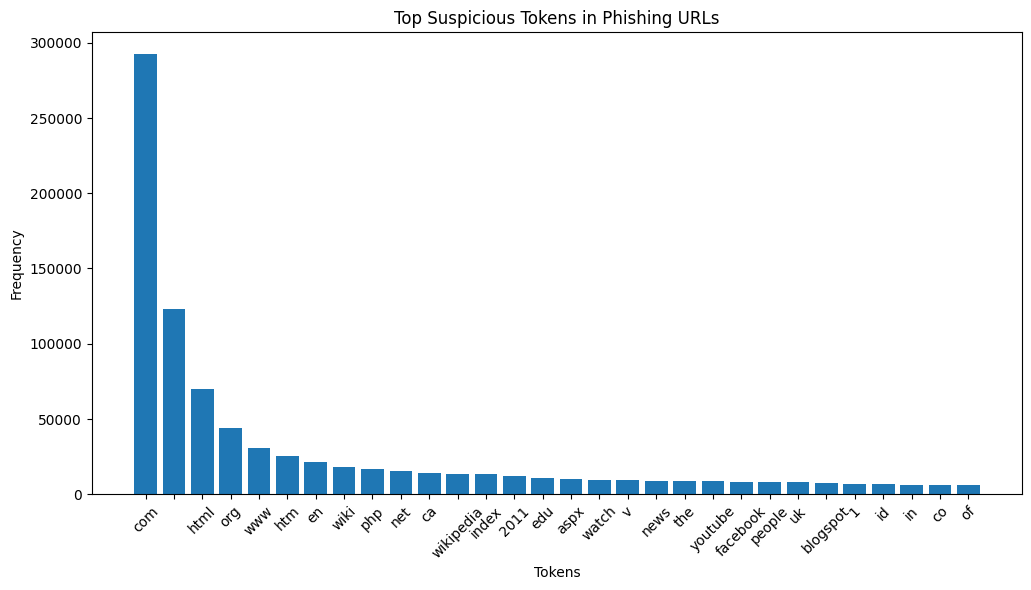

In [19]:
from collections import Counter
import matplotlib.pyplot as plt

# Filter only phishing rows (assuming 1 = phishing)
phishing_df = processed_df[processed_df["Label"] == 1]

# Flatten tokens from phishing URLs only
all_tokens = [token for sublist in phishing_df["tokens"] for token in sublist]

# Count frequency
token_counts = Counter(all_tokens)

# Top 30 tokens
top_tokens = token_counts.most_common(30)

words = [w for w, c in top_tokens]
counts = [c for w, c in top_tokens]

# Plot
plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Suspicious Tokens in Phishing URLs")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.show()

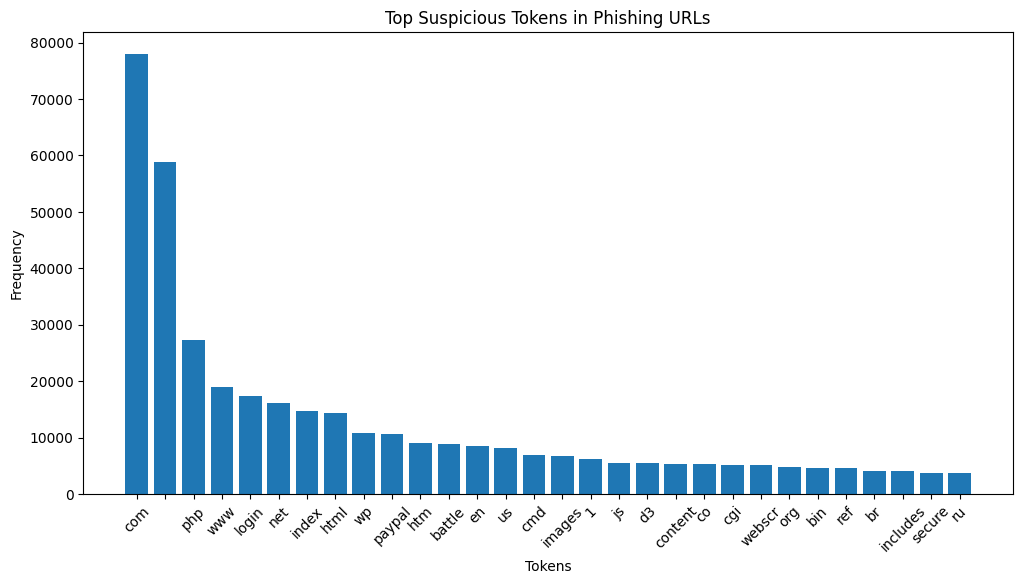

In [20]:
from collections import Counter
import matplotlib.pyplot as plt

# Filter only phishing rows (assuming 1 = phishing)
phishing_df = processed_df[processed_df["Label"] == 0]

# Flatten tokens from phishing URLs only
all_tokens = [token for sublist in phishing_df["tokens"] for token in sublist]

# Count frequency
token_counts = Counter(all_tokens)

# Top 30 tokens
top_tokens = token_counts.most_common(30)

words = [w for w, c in top_tokens]
counts = [c for w, c in top_tokens]

# Plot
plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top Suspicious Tokens in Phishing URLs")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.show()

In [21]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix 

In [22]:
X = processed_df.drop(['Label', 'URL','URL_clean','tokens'], axis=1)
y = processed_df['Label'] 

In [23]:
X.columns 

Index(['length', 'dot_count', 'hyphen_count', 'slash_count', 'digit_count',
       'suspicious_word_count'],
      dtype='object')

In [24]:
# 2. Split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

In [25]:
print(X_train.shape) 
print(X_test.shape)
print(y_train.shape)
print(y_test.shape) 

(405756, 6)
(101440, 6)
(405756,)
(101440,)


In [26]:
X_train.columns 

Index(['length', 'dot_count', 'hyphen_count', 'slash_count', 'digit_count',
       'suspicious_word_count'],
      dtype='object')

In [27]:
import pandas as pd

train_df = pd.concat([X_train, y_train], axis=1) 

In [28]:
# Separate classes
df_class_0 = train_df[train_df['Label'] == 0]
df_class_1 = train_df[train_df['Label'] == 1]

# Find smallest class size
min_count = min(len(df_class_0), len(df_class_1))

# Downsample both classes
df_class_0_down = df_class_0.sample(min_count, random_state=42)
df_class_1_down = df_class_1.sample(min_count, random_state=42)

# Combine
train_downsampled = pd.concat([df_class_0_down, df_class_1_down])

# Shuffle
train_downsampled = train_downsampled.sample(frac=1, random_state=42) 

In [29]:
X_train = train_downsampled.drop('Label', axis=1)
y_train = train_downsampled['Label'] 

In [30]:
y_train.value_counts()

Label
1    91439
0    91439
Name: count, dtype: int64

In [31]:
X_train.head()

,length,dot_count,hyphen_count,slash_count,digit_count,suspicious_word_count
442615,47,2,0,3,4,0
62408,35,3,0,1,4,0
213983,23,2,0,1,0,0
24246,141,3,5,3,19,0
27132,239,8,4,7,51,2


In [32]:
X_train.shape 

(182878, 6)

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV 

In [49]:
rf = RandomForestClassifier()

parameters = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 4, 8, 16, 32],
    "random_state": [42]
}

cv_rf = GridSearchCV(rf, parameters, cv=10) 
cv_rf.fit(X_train, y_train)  

GridSearchCV(cv=10, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [2, 4, 8, 16, 32],
                         'n_estimators': [50, 100, 200], 'random_state': [42]})

In [51]:
y_pred_rf = cv_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))  

              precision    recall  f1-score   support

           0       0.61      0.74      0.67     22860
           1       0.92      0.86      0.89     78580

    accuracy                           0.84    101440
   macro avg       0.77      0.80      0.78    101440
weighted avg       0.85      0.84      0.84    101440



In [35]:
lr = LogisticRegression()

parameters = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
    "max_iter": [1000]
}

cv_lr = GridSearchCV(lr, parameters, cv=10)
cv_lr.fit(X_train, y_train)   

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'max_iter': [1000],
                         'penalty': ['l2'], 'solver': ['lbfgs']})

In [37]:
y_pred_lr= cv_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))   

              precision    recall  f1-score   support

           0       0.47      0.56      0.51     22860
           1       0.87      0.82      0.84     78580

    accuracy                           0.76    101440
   macro avg       0.67      0.69      0.68    101440
weighted avg       0.78      0.76      0.77    101440



In [38]:
dt= DecisionTreeClassifier()

parameters = {
    "max_depth": [2,4,8,16,32],
    "random_state": [42]
}

cv_dt= GridSearchCV(dt, parameters, cv=10)
cv_dt.fit(X_train, y_train)   

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [2, 4, 8, 16, 32], 'random_state': [42]})

In [40]:
y_pred_dt = cv_dt.predict(X_test)
print(classification_report(y_test, y_pred_dt))    

              precision    recall  f1-score   support

           0       0.59      0.74      0.66     22860
           1       0.92      0.85      0.88     78580

    accuracy                           0.82    101440
   macro avg       0.75      0.80      0.77    101440
weighted avg       0.84      0.82      0.83    101440



In [55]:
best_model_rf = cv_rf.best_estimator_ 
print(best_model_rf) 
best_model_lr = cv_lr.best_estimator_ 
print(best_model_lr) 
best_model_dt = cv_dt.best_estimator_ 
print(best_model_dt)  

RandomForestClassifier(max_depth=16, n_estimators=200, random_state=42)
LogisticRegression(C=0.01, max_iter=1000)
DecisionTreeClassifier(max_depth=16, random_state=42)


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=axes[0]
)
axes[0].set_title("Random Forest")

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=axes[1]
)
axes[1].set_title("Logistic Regression")

# Decision Tree
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, ax=axes[2]
)
axes[2].set_title("Decision Tree")

plt.tight_layout()
plt.show() 

In [ ]:
import shap

# Create explainer for tree models
explainer = shap.TreeExplainer(best_model_rf)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# Plot summary (global feature importance)
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, plot_type="bar") 

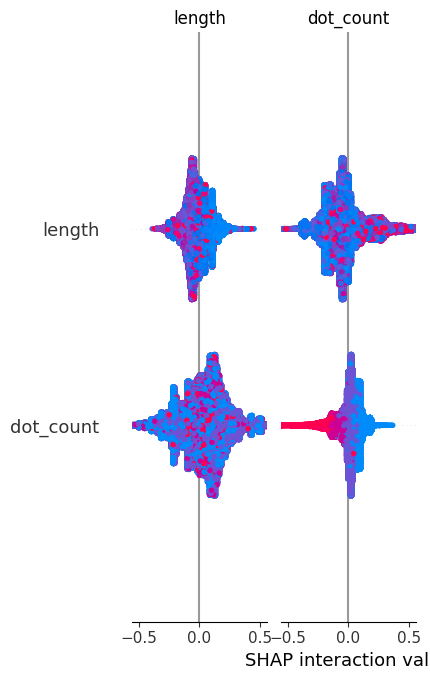

In [48]:
import shap

# Create explainer for tree models
explainer = shap.TreeExplainer(best_model_dt)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

# Plot summary (global feature importance)
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, plot_type="bar") 

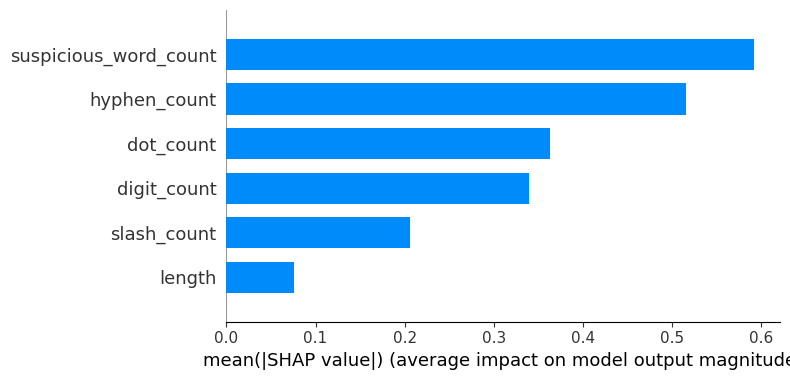

In [47]:
import shap

# Create explainer (for linear models)
explainer = shap.LinearExplainer(best_model_lr, X_train)

# Compute SHAP values
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X_test.columns, plot_type="bar") 